# Modeling and Evaluation Summary

This notebook documents Stage 10 and Stage 11 evidence after the methodological hardening pass.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

metadata = json.loads((PROJECT_ROOT / "model/model_metadata.json").read_text())
print({
    "selected_model": metadata["model_name"],
    "selection_method": metadata["selection_method"],
    "development_period": (metadata["development_start"], metadata["development_end"]),
    "final_test_period": (metadata["final_test_start"], metadata["final_test_end"]),
})

{'selected_model': 'random_forest', 'selection_method': 'TimeSeriesSplit validation inside the development period only', 'development_period': ('2018-02-01', '2024-11-27'), 'final_test_period': ('2024-11-29', '2026-08-19')}


## Time-aware model selection

Candidate models are selected only inside the development period using `TimeSeriesSplit`. The final test period is not used to choose between Linear Regression, Ridge, and Random Forest.

,model,validation_MAE,validation_RMSE,validation_R2,validation_MAE_std,validation_RMSE_std,folds,selection_rank
0,random_forest,0.004317,0.006086,-0.083486,0.001677,0.003499,5,1
1,ridge,0.005326,0.008896,-0.769791,0.003429,0.008921,5,2
2,linear_regression,0.005644,0.009916,-1.068475,0.003977,0.011027,5,3


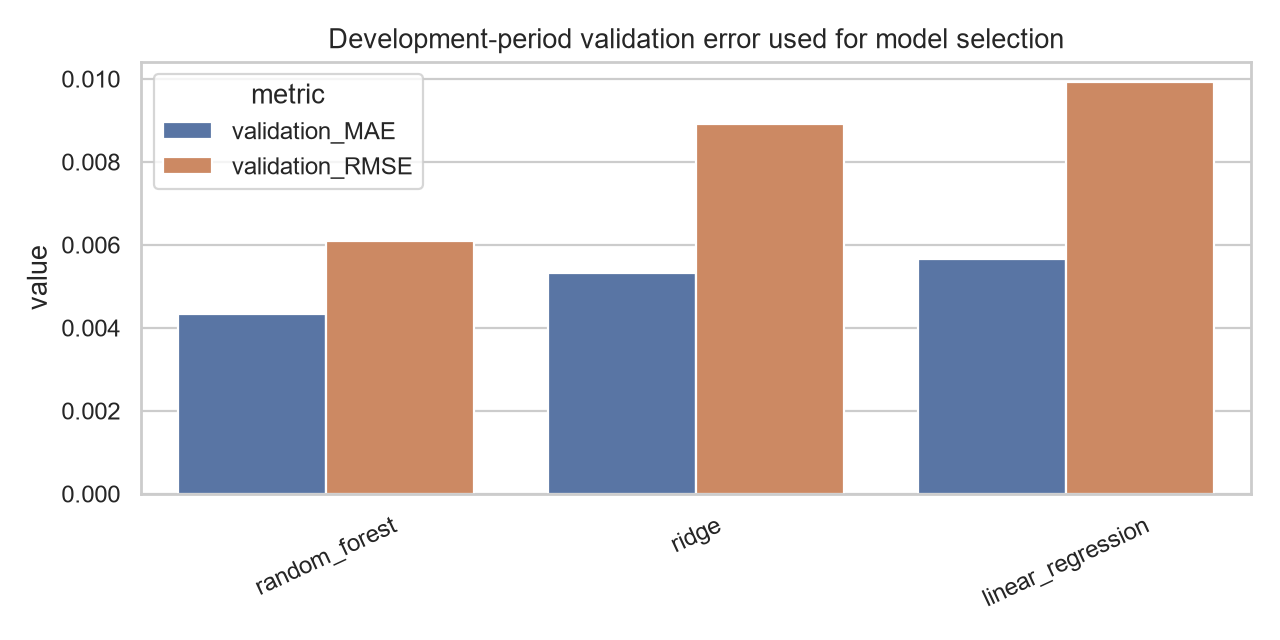

In [2]:
validation = pd.read_csv(PROJECT_ROOT / "reports/tables/model_validation_metrics.csv")
display(validation.round(6))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/model_validation_comparison.png")))

## Final untouched test evaluation

After validation chooses the model, the selected model is refit on the full development period and evaluated once on the final chronological test period. The naive persistence model remains the external benchmark.

,model,role,MAE,RMSE,R2,MAE_improvement_vs_naive,RMSE_improvement_vs_naive
0,naive_last_5d_realized_vol,external_benchmark,0.003855,0.006342,-0.175610,0.000000,0.000000
1,random_forest,selected_by_development_validation,0.003532,0.006555,-0.255827,0.083735,-0.033554


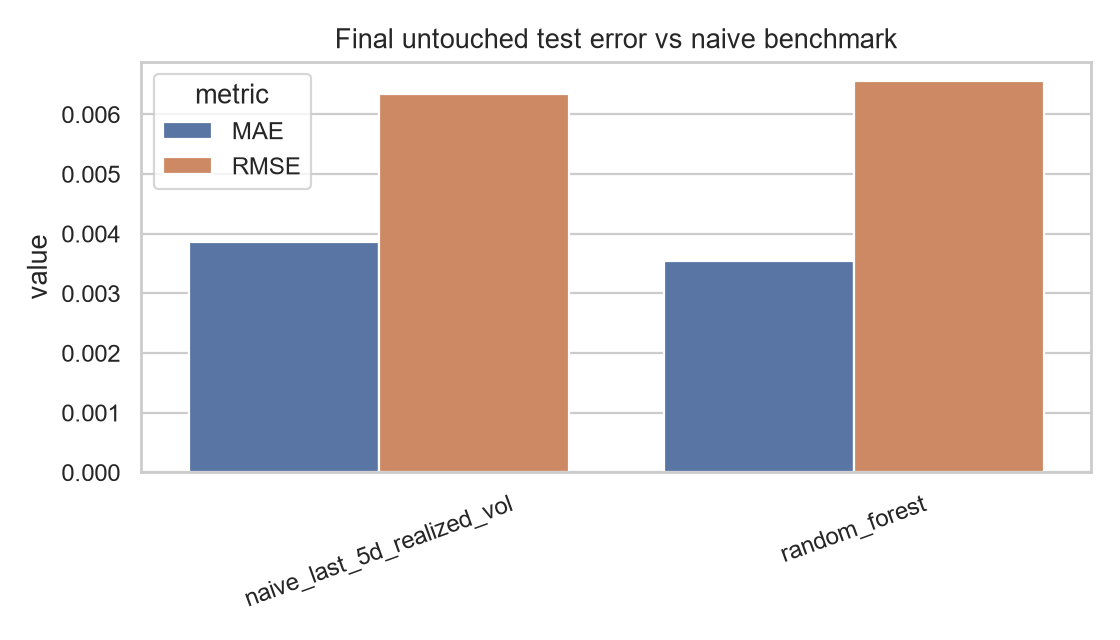

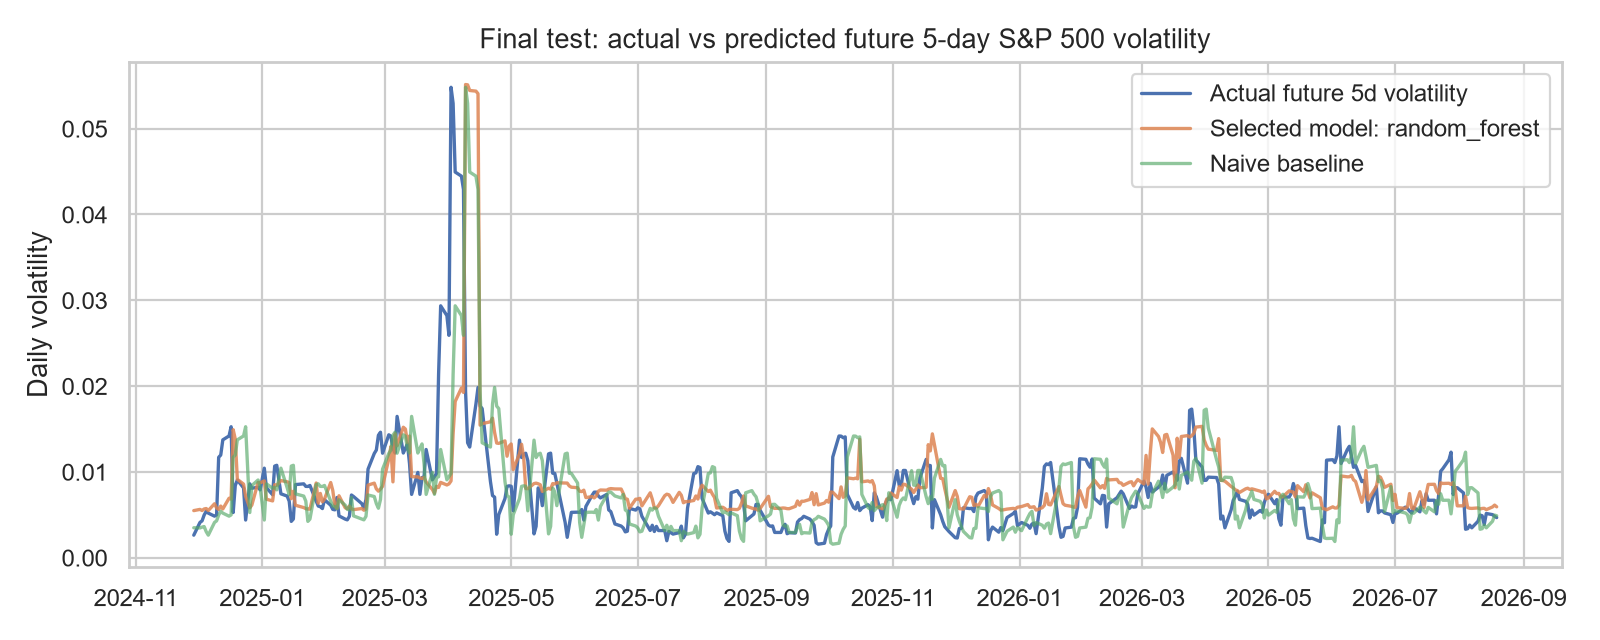

In [3]:
test = pd.read_csv(PROJECT_ROOT / "reports/tables/model_test_metrics.csv")
display(test.round(6))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/model_error_comparison.png")))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/actual_vs_predicted_volatility.png")))

## Coefficient Interpretation

The table below reports standardized coefficients for the linear regression track. Because Linear Regression and Ridge use `StandardScaler`, coefficient magnitudes are comparable across features after median imputation and scaling.

The strongest positive coefficients identify variables with the largest conditional predictive association with future volatility inside the fitted linear model. Negative coefficients move in the opposite direction conditional on the other features. These signs should be interpreted carefully because volatility features, VIX features, and interaction terms are correlated.

Ridge shrinks coefficients relative to ordinary least squares, which can reduce instability when predictors are multicollinear. These coefficients describe conditional predictive associations within this model. They should not be interpreted as causal effects of VIX or interest rates on future volatility.

,model,feature,coefficient,abs_coefficient,sign,rank_abs_magnitude
0,linear_regression,vix_close,0.003131,0.003131,positive,1
1,linear_regression,realized_volatility_10d,0.001804,0.001804,positive,2
2,linear_regression,vix_x_realized_vol_5d,0.000833,0.000833,positive,3
3,linear_regression,yield_spread_10y_2y,-0.000568,0.000568,negative,4
4,linear_regression,sp500_return_rolling_mean_5,-0.000558,0.000558,negative,5
5,linear_regression,sp500_return_lag_1,-0.000534,0.000534,negative,6
6,linear_regression,realized_volatility_21d,-0.000526,0.000526,negative,7
7,linear_regression,vix_pct_change,0.000303,0.000303,positive,8
14,ridge,vix_close,0.003121,0.003121,positive,1
15,ridge,realized_volatility_10d,0.001792,0.001792,positive,2


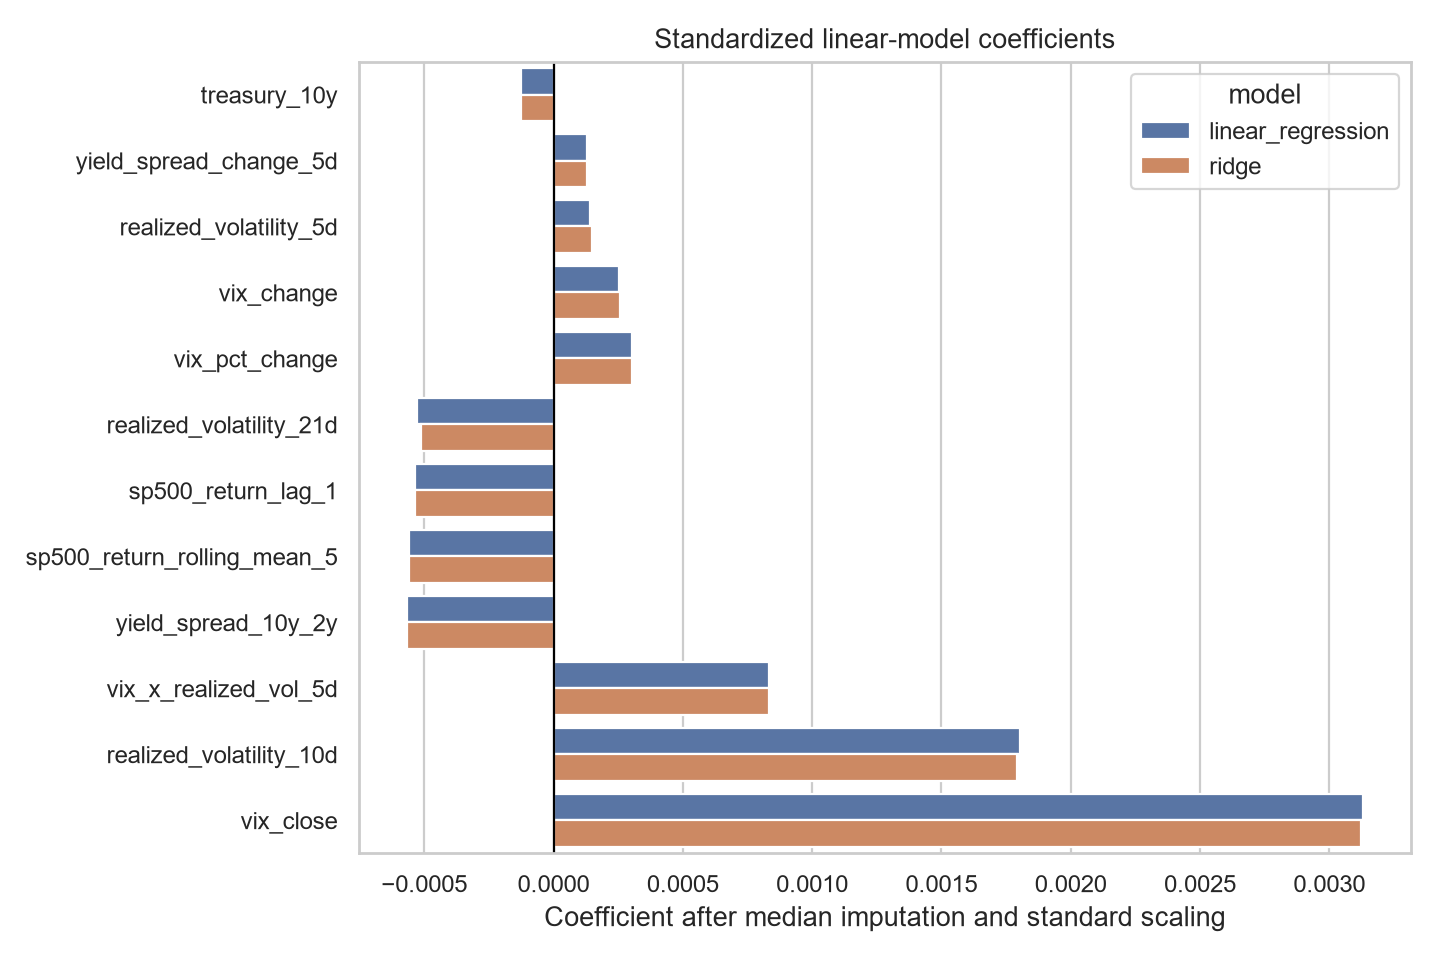

In [4]:
coefs = pd.read_csv(PROJECT_ROOT / "reports/tables/linear_coefficients.csv")
display(coefs.sort_values(["model", "rank_abs_magnitude"]).groupby("model").head(8).round(6))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/linear_coefficients.png")))

## Stage 11 assumption sensitivity

The scenarios below change one practical assumption at a time while preserving the same final untouched test period.

,scenario,model,feature_count,train_rows,test_rows,test_start,test_end,MAE,RMSE,bias,delta_MAE_vs_baseline,delta_RMSE_vs_baseline,interpretation
0,"Baseline: selected model, full feature set, fu...",random_forest,14,1718,430,2024-11-29,2026-08-19,0.003532,0.006555,-0.000973,0.000000,0.000000,"Prediction holds if all approved market, volat..."
1,No Treasury/yield information,random_forest,10,1718,430,2024-11-29,2026-08-19,0.003265,0.006449,-0.000365,-0.000267,-0.000105,Tests sensitivity to losing interest-rate leve...
2,Shorter training history: 2020 onward,random_forest,14,1236,430,2024-11-29,2026-08-19,0.003413,0.006513,-0.000573,-0.000119,-0.000042,Tests whether older market regimes are helping...


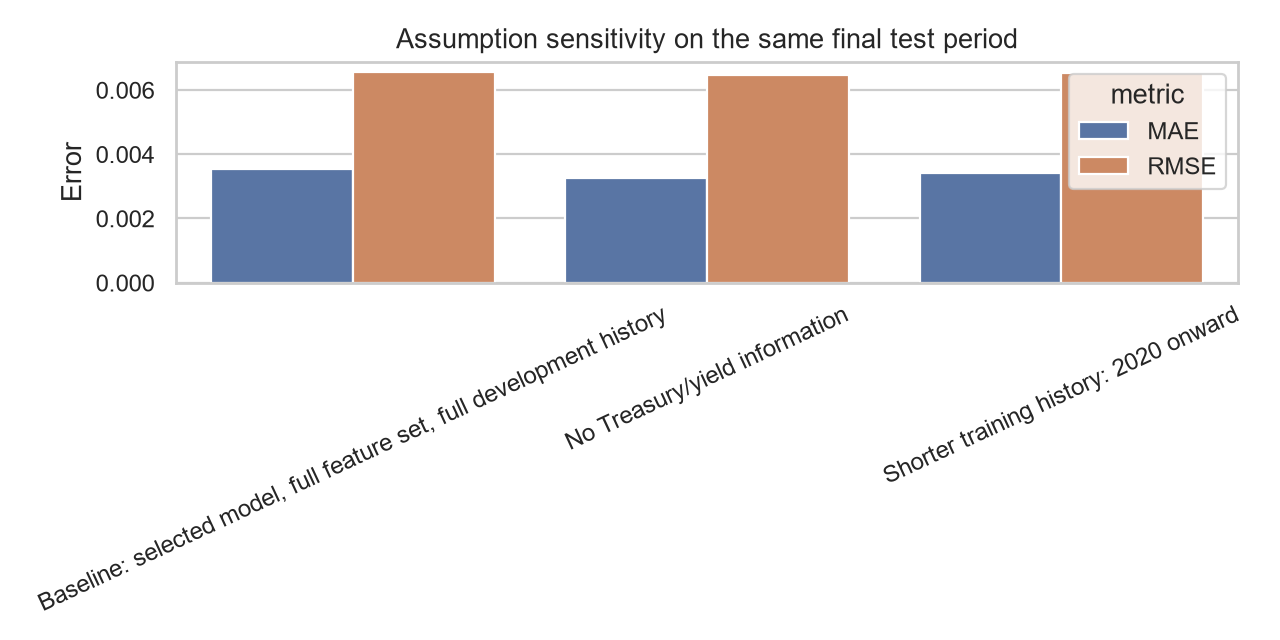

In [5]:
assumption = pd.read_csv(PROJECT_ROOT / "reports/tables/assumption_sensitivity.csv")
display(assumption.round(6))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/assumption_sensitivity.png")))

## Regime / subgroup diagnostics

These diagnostics slice the same final-test predictions by market condition. They are useful for risk communication but are intentionally separate from assumption sensitivity.

,subgroup,n,selected_MAE,selected_RMSE,selected_bias,naive_MAE,MAE_improvement_vs_naive
0,All final-test observations,430,0.003532,0.006555,-0.000973,0.003855,0.083735
1,Low/normal VIX regime,366,0.002678,0.004212,-0.000442,0.003308,0.190624
2,High VIX regime,64,0.008419,0.013682,-0.004008,0.006982,-0.205903
3,High realized-volatility regime,85,0.006619,0.011982,-0.002618,0.007612,0.130391


,mae,bootstrap_mean,ci_lower,ci_upper,n_bootstrap
0,0.003532,0.003526,0.00302,0.004048,1000


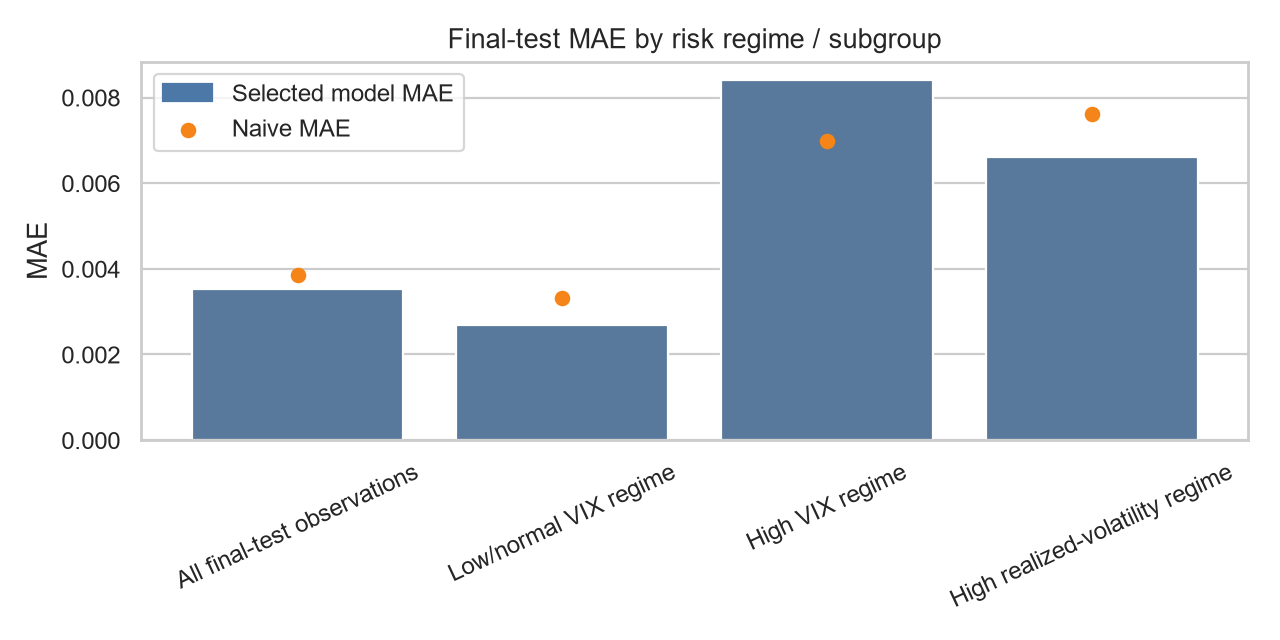

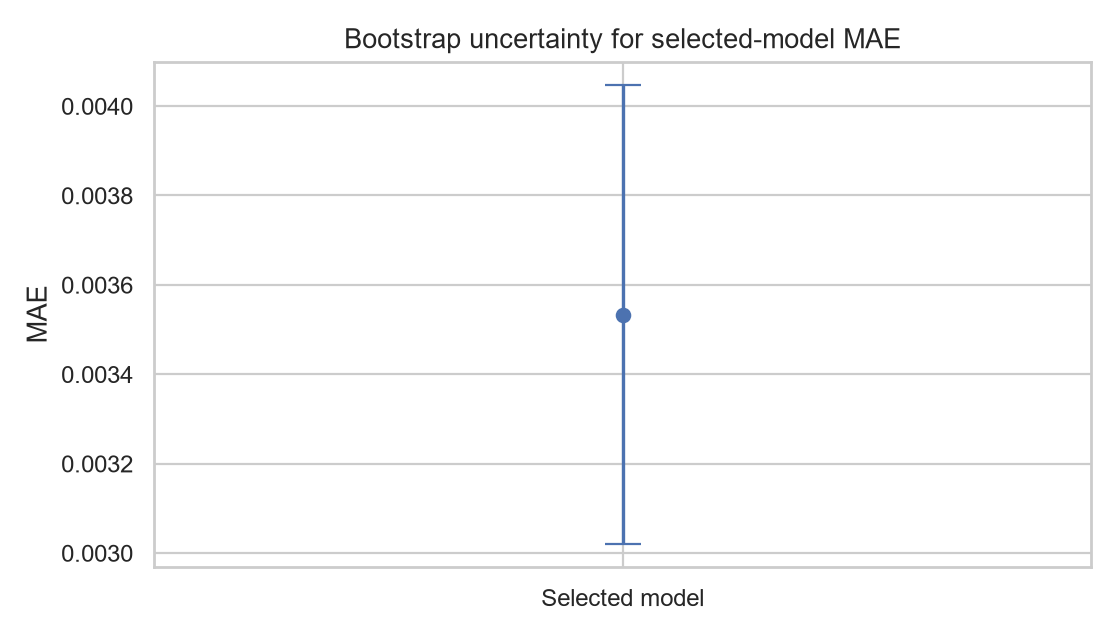

In [6]:
regime = pd.read_csv(PROJECT_ROOT / "reports/tables/regime_subgroup_metrics.csv")
ci = pd.read_csv(PROJECT_ROOT / "reports/tables/bootstrap_mae_ci.csv")
display(regime.round(6))
display(ci.round(6))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/scenario_mae_by_regime.png")))
display(Image(filename=str(PROJECT_ROOT / "reports/figures/bootstrap_mae_ci.png")))